# OAT 3 — Machine Learning para previsão de manutenções — MecâniQA

**Objetivo:** treinar modelos iniciais de regressão com hiperparâmetros padrão, respeitando a ordem temporal dos dados, e avaliar o desempenho por **RMSE** e **MAPE**.

## 🧠 Brainstorm guiado

### 1. A Escolha do Algoritmo
**Decisão da Equipe:** Utilizaremos os modelos **Random Forest Regressor** e **Gradient Boosting Regressor**, pois conseguem aprender relações não lineares. Com as features temporais, como lags, médias móveis e calendário, esses modelos podem identificar padrões de demanda e sazonalidade das manutenções.

### 2. A Linha do Tempo
**Decisão da Equipe:** Os dados serão ordenados cronologicamente e divididos sem embaralhamento. Os registros mais antigos serão usados para treinamento e os mais recentes para teste. As médias móveis serão calculadas após `shift(1)`, garantindo que cada linha use apenas informações conhecidas até o dia anterior e evitando **Data Leakage**.

In [1]:
# Bibliotecas
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)

## 1. Carregamento dos dados

A célula abaixo procura automaticamente por `mecaniqa_dataset.csv` na pasta atual e nas subpastas do projeto.

In [2]:
arquivos = list(Path(".").rglob("mecaniqa_dataset.csv"))

if not arquivos:
    raise FileNotFoundError(
        "mecaniqa_dataset.csv não encontrado. Coloque o oat3.ipynb na pasta do projeto MecâniQA."
    )

caminho = arquivos[0]
print("Dataset encontrado em:", caminho)

df = pd.read_csv(caminho)
print("Dimensão original:", df.shape)
display(df.head())
print("Colunas:", list(df.columns))

Dataset encontrado em: mecaniqa_dataset.csv
Dimensão original: (731, 3)


,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


Colunas: ['Data', 'Trocas_Oleo', 'Manutencao_Motor']


## 2. Preparação temporal e criação das features

As features de atraso (**lags**) e médias móveis são construídas usando apenas valores anteriores. O `shift(1)` nas médias móveis é essencial para impedir que o valor do próprio dia entre na previsão.

In [3]:
# Identifica a coluna de data
possiveis_datas = [c for c in df.columns if c.lower() in {"data", "date", "data_servico", "data_atendimento"}]
if not possiveis_datas:
    raise ValueError("Não foi possível identificar a coluna de data automaticamente.")

col_data = possiveis_datas[0]
df[col_data] = pd.to_datetime(df[col_data], dayfirst=True, errors="coerce")
df = df.dropna(subset=[col_data]).sort_values(col_data).set_index(col_data)

alvos = ["Trocas_Oleo", "Manutencao_Motor"]
for alvo in alvos:
    if alvo not in df.columns:
        raise ValueError(f"Coluna esperada não encontrada: {alvo}")

for alvo in alvos:
    df[f"{alvo}_lag_1"] = df[alvo].shift(1)
    df[f"{alvo}_lag_7"] = df[alvo].shift(7)
    df[f"{alvo}_lag_30"] = df[alvo].shift(30)
    df[f"{alvo}_media_7"] = df[alvo].shift(1).rolling(7).mean()
    df[f"{alvo}_media_30"] = df[alvo].shift(1).rolling(30).mean()

# Features de calendário
df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month
df["dia_mes"] = df.index.day

features = [
    "Trocas_Oleo_lag_1", "Trocas_Oleo_lag_7", "Trocas_Oleo_lag_30",
    "Trocas_Oleo_media_7", "Trocas_Oleo_media_30",
    "Manutencao_Motor_lag_1", "Manutencao_Motor_lag_7", "Manutencao_Motor_lag_30",
    "Manutencao_Motor_media_7", "Manutencao_Motor_media_30",
    "dia_semana", "mes", "dia_mes"
]

df_final = df.dropna(subset=features + alvos).copy()
print("Dimensão após criação das features:", df_final.shape)
display(df_final[alvos + features].head())

Dimensão após criação das features: (203, 15)


,Trocas_Oleo,Manutencao_Motor,Trocas_Oleo_lag_1,Trocas_Oleo_lag_7,Trocas_Oleo_lag_30,Trocas_Oleo_media_7,Trocas_Oleo_media_30,Manutencao_Motor_lag_1,Manutencao_Motor_lag_7,Manutencao_Motor_lag_30,Manutencao_Motor_media_7,Manutencao_Motor_media_30,dia_semana,mes,dia_mes
Data,,,,,,,,,,,,,,,
2024-03-07,13.0,5.0,19.0,12.0,11.0,22.285714,21.033333,11.0,7.0,2.0,9.142857,8.333333,3,3,7
2024-03-08,27.0,7.0,13.0,12.0,21.0,22.428571,21.100000,5.0,1.0,13.0,8.857143,8.433333,4,3,8
2024-03-09,6.0,-2.0,27.0,28.0,33.0,24.571429,21.300000,7.0,13.0,13.0,9.714286,8.233333,5,3,9
2024-03-10,8.0,4.0,6.0,32.0,25.0,21.428571,20.400000,-2.0,10.0,14.0,7.571429,7.733333,6,3,10
2024-03-11,23.0,9.0,8.0,21.0,19.0,18.000000,19.833333,4.0,7.0,6.0,6.714286,7.400000,0,3,11


## 3. Divisão temporal: treino e teste

Usaremos os **80% registros mais antigos para treino** e os **20% mais recentes para teste**. Não há embaralhamento dos dados.

In [4]:
corte = int(len(df_final) * 0.80)

treino = df_final.iloc[:corte].copy()
teste = df_final.iloc[corte:].copy()

X_treino = treino[features]
X_teste = teste[features]

print(f"Treino: {len(treino)} registros | {treino.index.min().date()} até {treino.index.max().date()}")
print(f"Teste : {len(teste)} registros | {teste.index.min().date()} até {teste.index.max().date()}")

assert treino.index.max() < teste.index.min(), "Erro: a divisão temporal não foi respeitada."
print("✓ Divisão temporal validada: treino ocorre antes do teste.")

Treino: 162 registros | 2024-03-07 até 2025-09-07
Teste : 41 registros | 2025-09-08 até 2025-12-12
✓ Divisão temporal validada: treino ocorre antes do teste.


## 4. Modelos de Machine Learning


In [5]:
def novos_modelos():
    return {
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42)
    }

novos_modelos()

{'Random Forest': RandomForestRegressor(random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42)}

Treinamento (`fit`) e previsões (`predict`)



In [ ]:
resultados = []
previsoes_modelos = {}

for alvo in alvos:
    y_treino = treino[alvo]
    y_teste = teste[alvo]

    for nome, modelo in novos_modelos().items():
        modelo.fit(X_treino, y_treino)
        previsoes = modelo.predict(X_teste)

        rmse = np.sqrt(mean_squared_error(y_teste, previsoes))

        mascara = y_teste != 0
        mape = mean_absolute_percentage_error(
            y_teste[mascara], previsoes[mascara]
        ) * 100

        resultados.append({
            "Série": alvo,
            "Modelo": nome,
            "RMSE": rmse,
            "MAPE (%)": mape
        })
        previsoes_modelos[(alvo, nome)] = previsoes

resultados_df = pd.DataFrame(resultados)
display(resultados_df.round(2))

,Série,Modelo,RMSE,MAPE (%)
0,Trocas_Oleo,Random Forest,7.21,22.22
1,Trocas_Oleo,Gradient Boosting,7.28,21.92
2,Manutencao_Motor,Random Forest,3.22,29.03
3,Manutencao_Motor,Gradient Boosting,3.95,31.61


Comparação visual do RMSE

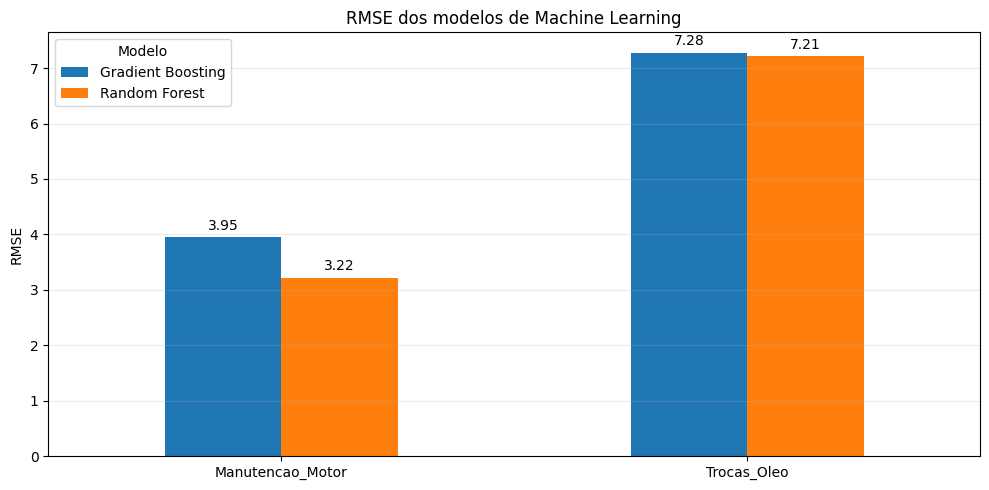

In [7]:
grafico = resultados_df.pivot(index="Série", columns="Modelo", values="RMSE")
ax = grafico.plot(kind="bar", figsize=(10, 5))
plt.title("RMSE dos modelos de Machine Learning")
plt.ylabel("RMSE")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

Real × previsto

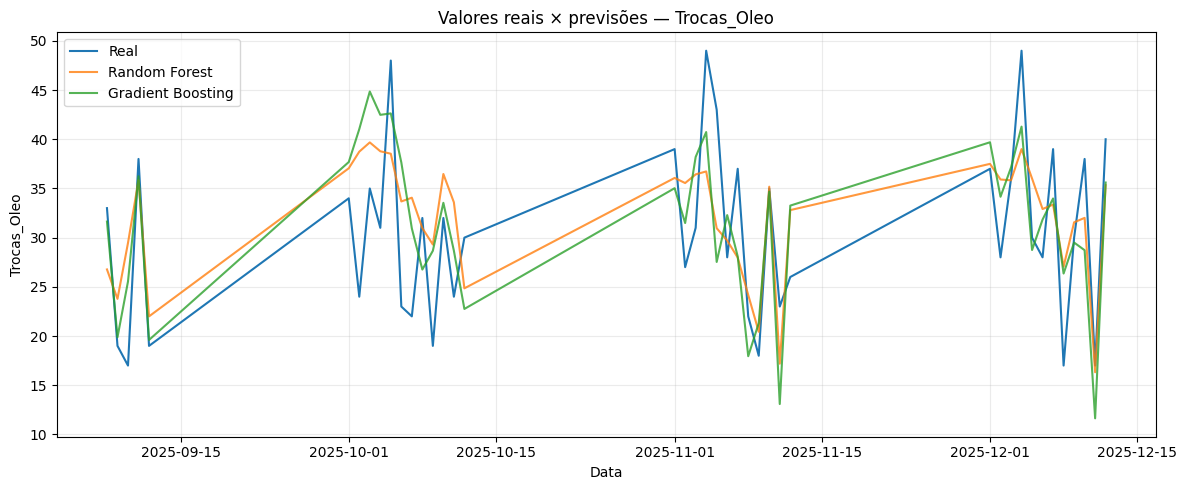

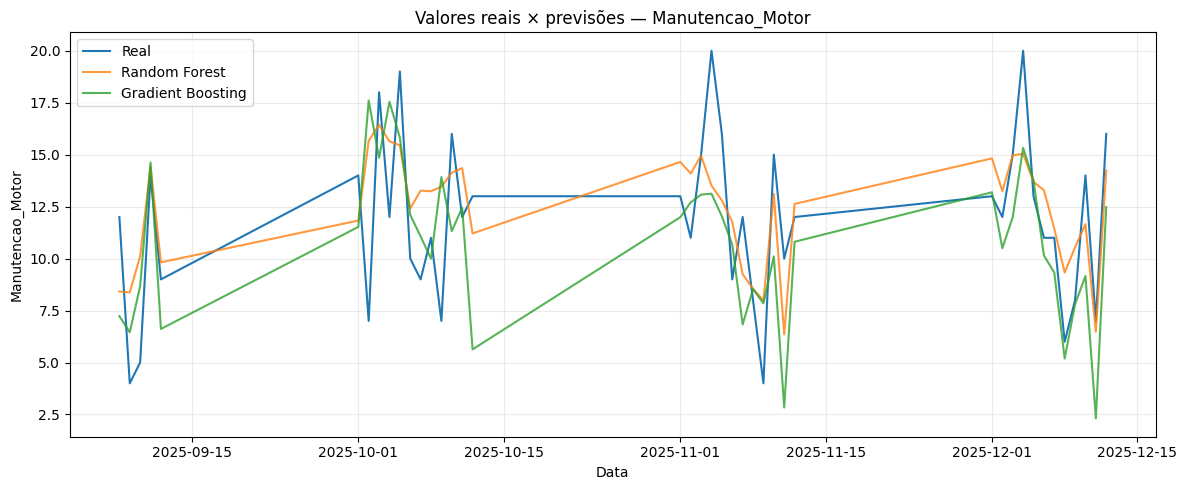

In [8]:
for alvo in alvos:
    plt.figure(figsize=(12, 5))
    plt.plot(teste.index, teste[alvo], label="Real")
    for nome in novos_modelos().keys():
        plt.plot(teste.index, previsoes_modelos[(alvo, nome)], label=nome, alpha=0.8)
    plt.title(f"Valores reais × previsões — {alvo}")
    plt.xlabel("Data")
    plt.ylabel(alvo)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()